# Deteção de Texto IA vs Humano — Regressão Logística

**Estratégia baseline** com representação TF-IDF e regressão logística em PyTorch.

**Classes:** `Human`, `Google`, `Meta`, `Anthropic`

**Pipeline:**
```
Texto → Limpeza → TF-IDF → SimpleClassifier (Linear) → CrossEntropyLoss
```

## 1. Imports

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Configuração

In [2]:
DATA_PATH   = "data/dataset-exemplos.csv"
TEXT_COL    = "Text"
LABEL_COL   = "Label"
CLASSES     = ["Human", "Google", "Meta", "Anthropic", "OpenAI"]
N_CLASSES   = len(CLASSES)

MAX_WORDS   = 20000           # vocabulário TF-IDF 
BATCH_SIZE  = 64
EPOCHS      = 30
LR          = 0.001
VAL_SPLIT   = 0.8             # 80% treino, 20% validação
TEST_SPLIT  = 0.1             # 10% do total reservado para teste
SEED        = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(SEED)

Device: cpu


## 3. Carregamento e Pré-processamento dos Dados

In [3]:
def clean_text(text):
    """Limpeza básica do texto — igual ao imdb-torch-full.py"""
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)       # remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text)    # mantém apenas letras
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Carregar CSV
df = pd.read_csv(DATA_PATH, sep=";")
print(f"Dataset shape: {df.shape}")
print(f"\nDistribuição de classes:")
print(df[LABEL_COL].value_counts())

# Limpeza do texto
df["clean_text"] = df[TEXT_COL].astype(str).apply(clean_text)

# Codificar labels em inteiros (0..N-1)
le = LabelEncoder()
le.fit(CLASSES)   # garante ordem consistente
df["label_enc"] = le.transform(df[LABEL_COL])

print(f"\nMapeamento de classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
df.head(3)

Dataset shape: (125, 3)

Distribuição de classes:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64

Mapeamento de classes: {np.str_('Anthropic'): np.int64(0), np.str_('Google'): np.int64(1), np.str_('Human'): np.int64(2), np.str_('Meta'): np.int64(3), np.str_('OpenAI'): np.int64(4)}


,ID,Text,Label,clean_text,label_enc
0,D1-1,"It is an approximation useful in chemistry, bu...",Human,it is an approximation useful in chemistry but...,2
1,D1-2,"PET scanning, or Positron Emission Tomography,...",Meta,pet scanning or positron emission tomography i...,3
2,D1-3,Positron Emission Tomography (PET) scanning is...,Google,positron emission tomography pet scanning is a...,1


## 4. Divisão Treino / Validação / Teste

In [4]:
from sklearn.model_selection import train_test_split

texts = df["clean_text"].tolist()
labels = df["label_enc"].tolist()

# Separar teste primeiro
texts_trainval, texts_test, labels_trainval, labels_test = train_test_split(
    texts, labels, test_size=TEST_SPLIT, random_state=SEED, stratify=labels
)

# Separar treino / validação
val_ratio = 1 - VAL_SPLIT          # fracção do trainval para validação
texts_train, texts_val, labels_train, labels_val = train_test_split(
    texts_trainval, labels_trainval, test_size=val_ratio, random_state=SEED, stratify=labels_trainval
)

print(f"Treino:    {len(texts_train):>5} exemplos")
print(f"Validação: {len(texts_val):>5} exemplos")
print(f"Teste:     {len(texts_test):>5} exemplos")

Treino:       89 exemplos
Validação:    23 exemplos
Teste:        13 exemplos


## 5. Representação TF-IDF e Dataset PyTorch

In [5]:
# Fit do vectorizador apenas nos dados de treino (evita data leakage)
vectorizer = TfidfVectorizer(
    max_features=MAX_WORDS,
    ngram_range=(1, 2),       # unigramas + bigramas
    stop_words="english",
    min_df=2
)
X_train = vectorizer.fit_transform(texts_train).toarray()
X_val   = vectorizer.transform(texts_val).toarray()
X_test  = vectorizer.transform(texts_test).toarray()

print(f"Shape TF-IDF treino: {X_train.shape}")

Shape TF-IDF treino: (89, 1191)


In [6]:
class TextDataset(Dataset):
    """Dataset genérico para features pré-computadas + labels inteiros (multiclasse)"""
    def __init__(self, X, labels):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)   # CrossEntropyLoss precisa de long

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TextDataset(X_train, labels_train)
val_dataset   = TextDataset(X_val,   labels_val)
test_dataset  = TextDataset(X_test,  labels_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

## 6. Modelo — Regressão Logística (SimpleClassifier)

In [7]:
class SimpleClassifier(nn.Module):
    """
    Regressão Logística Multiclasse.
    Uma única camada linear: input_dim → nclasses.
    (equivalente ao SimpleClassifier do imdb-torch-full.py, adaptado para multiclasse)
    """
    def __init__(self, input_dim, nclasses):
        super().__init__()
        self.linear = nn.Linear(input_dim, nclasses)

    def forward(self, x):
        return self.linear(x)   # logits — CrossEntropyLoss aplica softmax internamente


input_dim = X_train.shape[1]
model = SimpleClassifier(input_dim, N_CLASSES).to(device)
print(model)
print(f"\nParâmetros treináveis: {sum(p.numel() for p in model.parameters()):,}")

SimpleClassifier(
  (linear): Linear(in_features=1191, out_features=5, bias=True)
)

Parâmetros treináveis: 5,960


## 7. Treino e Avaliação

In [8]:
def evaluate(model, loader, criterion):
    """Calcula loss e accuracy num DataLoader — idêntico ao imdb-torch-full.py, adaptado para multiclasse"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)                          # logits: (B, nclasses)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)               # classe com maior logit
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total


def train(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, verbose=True):
    """Loop de treino — baseado no train() do imdb-torch-full.py"""
    criterion = nn.CrossEntropyLoss()                   # multiclasse (substitui BCELoss)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, train_loader, criterion)
        val_loss,   val_acc   = evaluate(model, val_loader,   criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if verbose and epoch % 5 == 0:
            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return history

In [9]:
history = train(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

Epoch 05/30 | Train Loss: 1.5651 Acc: 0.7079 | Val Loss: 1.5950 Acc: 0.3478
Epoch 10/30 | Train Loss: 1.5226 Acc: 0.7978 | Val Loss: 1.5899 Acc: 0.3478
Epoch 15/30 | Train Loss: 1.4799 Acc: 0.8315 | Val Loss: 1.5843 Acc: 0.3913
Epoch 20/30 | Train Loss: 1.4401 Acc: 0.8427 | Val Loss: 1.5796 Acc: 0.3913
Epoch 25/30 | Train Loss: 1.4095 Acc: 0.8315 | Val Loss: 1.5754 Acc: 0.3913
Epoch 30/30 | Train Loss: 1.3682 Acc: 0.8652 | Val Loss: 1.5713 Acc: 0.3913


## 8. Curvas de Aprendizagem

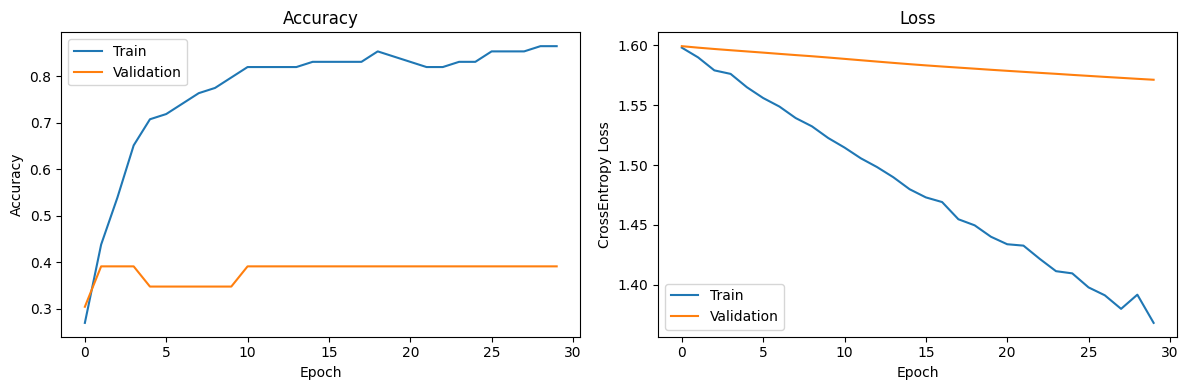

In [10]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_acc"], label="Train")
    axes[0].plot(history["val_acc"],   label="Validation")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history["train_loss"], label="Train")
    axes[1].plot(history["val_loss"],   label="Validation")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("CrossEntropy Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## 9. Avaliação no Conjunto de Teste

In [11]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.6214
Test Accuracy: 0.3077


In [12]:
# Classification report por classe
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=le.classes_))

              precision    recall  f1-score   support

   Anthropic       0.00      0.00      0.00         2
      Google       0.00      0.00      0.00         2
       Human       0.36      0.80      0.50         5
        Meta       0.00      0.00      0.00         2
      OpenAI       0.00      0.00      0.00         2

    accuracy                           0.31        13
   macro avg       0.07      0.16      0.10        13
weighted avg       0.14      0.31      0.19        13



/home/gabriel/miniconda3/envs/EC/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabriel/miniconda3/envs/EC/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabriel/miniconda3/envs/EC/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

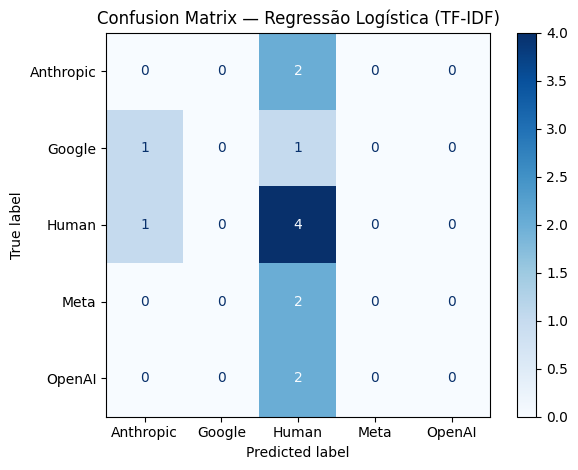

In [13]:
# Matriz de confusão
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Regressão Logística (TF-IDF)")
plt.tight_layout()
plt.show()

## 10. Inferência — Classificar Novo Texto

In [14]:
def predict_text(text, model, vectorizer, label_encoder, device):
    """Classifica um texto novo e devolve a classe prevista e as probabilidades."""
    model.eval()
    cleaned = clean_text(text)
    x = vectorizer.transform([cleaned]).toarray()
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(x_tensor)              # (1, nclasses)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()

    print(f"Classe prevista: {label_encoder.classes_[pred]}")
    print("Probabilidades:")
    for cls, p in zip(label_encoder.classes_, probs):
        print(f"  {cls:12s}: {p:.4f}")
    return label_encoder.classes_[pred], probs


# Exemplo
sample = "The advancements in large language models have been remarkable over the past few years."
predict_text(sample, model, vectorizer, le, device)

Classe prevista: Human
Probabilidades:
  Anthropic   : 0.2120
  Google      : 0.1739
  Human       : 0.2276
  Meta        : 0.1962
  OpenAI      : 0.1903


(np.str_('Human'),
 array([0.21197742, 0.17391227, 0.22758558, 0.19623789, 0.19028677],
       dtype=float32))